# Module 1: Algebraic Foundations

### The alias problem

We need people to be able to send us money. But they can't send it to our
private key — if we hand that out, anyone who sees it can spend our funds.
So we need an **alias**: a public identity derived from our private key that
people can send to, but that reveals nothing about the key itself.

```
  PRIVATE KEY (secret)          PUBLIC KEY (alias)
 ┌──────────────┐  d × G   ┌──────────────┐
 │   d  (256b)  │ ───────→ │   P  (point)  │   ← anyone can send to this
 └──────────────┘   easy    └──────────────┘
                  ←───────
                  impossible                      ← nobody can reverse it
```

That alias is the **public key**: $P = d \times G$, where $d$ is our secret and
$G$ is a known starting point. Anyone can send bitcoin to $P$. Nobody can work
backwards from $P$ to figure out $d$.

### The proof problem

When we want to spend, we need to **prove that $P$ really is our alias** — that
we know the $d$ behind it — without revealing $d$.

```
  SIGNING                           VERIFYING
 ┌──────────────────────┐     ┌──────────────────────────┐
 │  inputs:             │     │  inputs:                  │
 │    d  (private key)  │     │    P  (public key)        │
 │    tx (transaction)  │     │    tx (transaction)       │
 │                      │     │    (r, s) (signature)     │
 │  output:             │     │                           │
 │    (r, s) signature  │     │  output:                  │
 │                      │     │    ✓ valid  or  ✗ invalid │
 └──────────────────────┘     └──────────────────────────┘
      only the signer              anyone in the world
      can produce this             can check this
```

Elliptic curves give us exactly this. The operation $d \times G$ ("multiply a
point on a curve by a scalar") is easy to compute forward and impossible to
reverse. That's the one-way function.

### How we got here: from ElGamal to ECC

ECC didn't come out of nowhere. The idea of wiring a one-way function into a
sign/verify protocol was already solved before elliptic curves entered the
picture:

```
  1985: ElGamal                          1985: Koblitz & Miller
 ┌─────────────────────────┐            ┌─────────────────────────┐
 │  Group: integers mod p  │            │  Group: EC over F_p     │
 │  Hard problem: DLP      │            │  Hard problem: ECDLP    │
 │  Key size: 3072 bits    │            │  Key size: 256 bits     │
 │                         │  "Same     │                         │
 │  Abelian properties:    │  scheme,   │  Abelian properties:    │
 │  ✓ free (textbook       │  stronger  │  ✓ verified (had to     │
 │    since the 1800s)     │  group"    │    check they hold)     │
 └─────────────────────────┘ ────────→  └─────────────────────────┘
```

ElGamal built his signature scheme on the discrete log problem in plain
integers mod a prime. The math was already there — integers mod a prime under
multiplication naturally form an Abelian group (closure, associativity,
inverses, commutativity — all free, all textbook since the 1800s). He didn't
have to go looking for those properties; they came with the territory. His
innovation was the *scheme itself*.

The problem: the discrete log on integers mod $p$ can be attacked with
subexponential algorithms (index calculus), so you need enormous keys — 3072
bits — to stay safe.

Koblitz and Miller said: "Nice scheme. Same equations. But your group is weak —
let's swap it for a stronger one." They found that elliptic curves over finite
fields also form an Abelian group, but one where no subexponential attack is
known. Same security, 256-bit keys instead of 3072.

**That's when the group properties became an explicit checklist** — because now
you're transplanting a scheme into a new mathematical setting and you have to
verify the new setting still supports it.

**But just having a one-way function isn't enough.** If the math doesn't behave
well, the signature equations fall apart. For example:

- What if $d \times G$ produces a result that isn't even a valid point? Then
  our alias $P$ is nonsense. Consider the odd numbers: $\{1, 3, 5, 7, ...\}$.
  Multiplication is fine — $3 \times 5 = 15$, still odd. But addition breaks
  out: $5 + 5 = 10$, which isn't in the set. If your operation can escape the
  set, the whole system falls apart. And it's not just a math hygiene issue —
  **the security depends on staying inside a finite set where the outputs look
  random.** Over the real numbers, if $P$ is "far" from $G$, that leaks that
  $d$ is large. In a finite group, everything wraps around — there's no sense
  of "far" — so the output reveals nothing about the input.
- What if you can't compute inverses? Then the verification equation can't be
  rearranged to check the signature.
- What if the order of operations matters? Then the signer and verifier would
  get different answers from the same inputs.

To avoid all of this, we need to constrain the mathematical environment. We need
a system where:

| Property | What it guarantees | Why we need it |
|----------|-------------------|----------------|
| **Closure** | Combining two elements always gives another valid element | $d \times G$ is guaranteed to produce a valid point |
| **Associativity** | Grouping doesn't matter | The signing equation can be rearranged and simplified |
| **Identity** | There's a neutral "do nothing" element | We need a concept of zero — the point at infinity |
| **Inverse** | Every operation can be undone | Verification needs to compute $s^{-1}$ |
| **Commutativity** | Order doesn't matter | Signer and verifier arrive at the same result independently |

A system with the first four properties is called a **group**. Add commutativity
and it becomes an **Abelian group**. This is exactly the structure that points on
an elliptic curve form — and it's why we use elliptic curves for Bitcoin's
signatures rather than just any one-way function.

For the next while, we'll focus on what these properties are, how they work, and
how they combine to create the mathematical environment we need.

---

## 1.1 Groups

A **group** is a set $S$ with a binary operation $\cdot$ satisfying four axioms.
Add a fifth (commutativity) and it becomes an **Abelian group**:

| Axiom | Statement | Intuition |
|-------|-----------|----------|
| **Closure** | $\forall a,b \in S: a \cdot b \in S$ | Combining elements stays in the set |
| **Associativity** | $(a \cdot b) \cdot c = a \cdot (b \cdot c)$ | Grouping doesn't matter |
| **Identity** | $\exists e: a \cdot e = e \cdot a = a$ | There's a "do nothing" element |
| **Inverse** | $\forall a, \exists a^{-1}: a \cdot a^{-1} = e$ | Every action can be undone |
| **Commutativity** | $a \cdot b = b \cdot a$ | Order doesn't matter |

Let's work through each one using small numbers so the concepts are solid before
we connect them to elliptic curves.

### Closure

$\forall a,b \in S: a \cdot b \in S$ — combining two elements always gives
another element in the same set.

We'll use **integers mod 7** as our set: $\{0, 1, 2, 3, 4, 5, 6\}$, with
addition as the operation.

Why mod a prime? Because over the real numbers, results grow without bound —
and worse, a computer can't represent reals exactly. Floating-point errors
accumulate, and after enough operations, your result drifts off the curve.
Working mod a prime keeps everything in a **finite set** where every result
is exact. It also destroys any sense of "closeness" between inputs and outputs,
which is what makes the discrete log problem hard for attackers.

In [1]:
n = 7
S = list(range(n))
set_str = "{" + ", ".join(map(str, S)) + "}"

print(f"Set: Z_7 = {set_str}")
print(f"\n(3 + 5) mod 7 = {(3 + 5) % n}  ← still in the set  ✓")
print(f"(6 + 6) mod 7 = {(6 + 6) % n}  ← wraps around, still in the set  ✓")

print(f"\nCompare with odd numbers under addition:")
print(f"5 + 5 = 10  ← 10 is even, escaped the set  ✗  (closure violated)")
print(f"3 + 7 = 10  ← same problem")
print(f"\nThat's why we work mod a prime: the result always stays in the set.")

Set: Z_7 = {0, 1, 2, 3, 4, 5, 6}

(3 + 5) mod 7 = 1  ← still in the set  ✓
(6 + 6) mod 7 = 5  ← wraps around, still in the set  ✓

Compare with odd numbers under addition:
5 + 5 = 10  ← 10 is even, escaped the set  ✗  (closure violated)
3 + 7 = 10  ← same problem

That's why we work mod a prime: the result always stays in the set.


### Associativity

$(a \cdot b) \cdot c = a \cdot (b \cdot c)$ — grouping doesn't matter.

This one sounds boring, but it's essential. The ECDSA signing equation needs to
be rearranged during verification — terms get moved around, regrouped,
simplified. If the order you evaluate sub-expressions in changes the result,
the whole thing breaks. Associativity guarantees you can rearrange freely.

In [2]:
a, b, c = 2, 4, 6

left  = ((a + b) % n + c) % n   # (2+4) first, then +6
right = (a + (b + c) % n) % n   # (4+6) first, then +2

print(f"({a} + {b}) + {c}  mod 7 = {left}")
print(f" {a} + ({b} + {c}) mod 7 = {right}")
print(f"Same result: {left == right}  ✓")

(2 + 4) + 6  mod 7 = 5
 2 + (4 + 6) mod 7 = 5
Same result: True  ✓


### Identity

$\exists e: a \cdot e = e \cdot a = a$ — there's a "do nothing" element.

For addition mod 7, the identity is **0** — adding zero changes nothing.

On an elliptic curve, the identity is the **point at infinity** $\mathcal{O}$.
It plays the role of zero: adding it to any point gives back the same point.
We need this to define what it means for a point to have an inverse (the next
property), because "inverse" means "the thing that gets you back to the identity."

In [3]:
e = 0  # identity element for addition mod 7

for a in range(n):
    assert (a + e) % n == a
    assert (e + a) % n == a

print(f"Identity element: {e}")
print(f"5 + 0 = {(5 + 0) % n}  ✓")
print(f"0 + 3 = {(0 + 3) % n}  ✓")
print(f"Verified: a + 0 = 0 + a = a for every element in Z_7  ✓")

Identity element: 0
5 + 0 = 5  ✓
0 + 3 = 3  ✓
Verified: a + 0 = 0 + a = a for every element in Z_7  ✓


### Inverse

$\forall a, \exists a^{-1}: a \cdot a^{-1} = e$ — every element has a partner
that "undoes" it, bringing you back to the identity.

For addition mod 7: the inverse of 3 is 4, because $(3 + 4) \bmod 7 = 0$
(the identity).

This is critical for verification. When the verifier checks a signature, they
need to compute things like $s^{-1}$ — the multiplicative inverse of $s$. If
inverses didn't exist, the verification equation couldn't be solved.

In [4]:
print("Every element in Z_7 has an additive inverse:\n")
for a in range(n):
    inv = (n - a) % n
    print(f"  {a} + {inv} = {(a + inv) % n}  (mod 7)  → inverse of {a} is {inv}")

Every element in Z_7 has an additive inverse:

  0 + 0 = 0  (mod 7)  → inverse of 0 is 0
  1 + 6 = 0  (mod 7)  → inverse of 1 is 6
  2 + 5 = 0  (mod 7)  → inverse of 2 is 5
  3 + 4 = 0  (mod 7)  → inverse of 3 is 4
  4 + 3 = 0  (mod 7)  → inverse of 4 is 3
  5 + 2 = 0  (mod 7)  → inverse of 5 is 2
  6 + 1 = 0  (mod 7)  → inverse of 6 is 1


### Commutativity (the Abelian property)

$a \cdot b = b \cdot a$ — order doesn't matter.

This is what makes a group **Abelian**. The signer computes the signature using
one sequence of operations; the verifier checks it using a different sequence.
Both must arrive at the same result. If order mattered, they'd get different
answers from the same inputs — and verification would fail even for valid
signatures.

In [5]:
print("Commutativity check for all pairs in Z_7:\n")
all_commute = True
for a in range(n):
    for b in range(n):
        if (a + b) % n != (b + a) % n:
            all_commute = False

print(f"  2 + 5 = {(2+5)%n},  5 + 2 = {(5+2)%n}  ✓")
print(f"  4 + 6 = {(4+6)%n},  6 + 4 = {(6+4)%n}  ✓")
print(f"\n  All {n*n} pairs commute: {all_commute}  → Z_7 is Abelian  ✓")

Commutativity check for all pairs in Z_7:

  2 + 5 = 0,  5 + 2 = 0  ✓
  4 + 6 = 3,  6 + 4 = 3  ✓

  All 49 pairs commute: True  → Z_7 is Abelian  ✓


### All five at work: the ECDSA equation

Now we can see why every property matters. The signing equation in ECDSA is:

$$s = k^{-1}(z + r \cdot d) \bmod N$$

The verifier doesn't know $d$ or $k$. They rearrange this to:

$$R' = \frac{z}{s} \times G + \frac{r}{s} \times P$$

and check if $R'$ matches. That rearrangement uses:

| Step | Property used |
|------|--------------|
| $k^{-1}$ and $s^{-1}$ exist | **Inverse** |
| $\frac{z}{s} \times G$ produces a valid curve point | **Closure** |
| Terms can be regrouped and factored | **Associativity** |
| Adding the point at infinity when needed | **Identity** |
| Signer and verifier get the same result from different orderings | **Commutativity** |

Without any one of these, the equation either can't be formed, can't be
rearranged, or produces different answers on each side.

## The group needs a home

Groups give us one operation — point addition — and that's what the signature
scheme uses. Signing and verification are built entirely on adding and scaling
points.

But the curve has to **exist** first. The equation $y^2 = x^3 + ax + b$
defines which $(x, y)$ pairs are on the curve. To evaluate it, you need to
compute squares, cubes, additions, and multiplications of coordinates. And
the slope formula for adding two points requires division:
$\lambda = (y_2 - y_1) / (x_2 - x_1)$.

None of that is the group operation. It's the **number system the coordinates
live in** — the ground the curve is drawn on. The field is infrastructure.
The group is what we actually use. The field exists so the group can exist.

So what kind of number system do we need for the coordinates?

---

## 1.2 Rings — two operations

The curve equation $y^2 = x^3 + ax + b$ uses both **addition and
multiplication**. A group only gives us one operation. To even *write down*
the curve, we need a set where both are defined.

A **ring** is exactly that — a set with two operations where:
- Addition forms an Abelian group
- Multiplication is associative and distributes over addition

**Example: $\mathbb{F}_7$ as a ring.**
Take the set $\{0, 1, 2, 3, 4, 5, 6\}$ with arithmetic mod 7.
You can add: $5 + 4 = 9 \equiv 2 \pmod{7}$ — still in the set.
You can multiply: $3 \times 5 = 15 \equiv 1 \pmod{7}$ — still in the set.
Distributing works: $3 \times (4 + 5) \equiv 3 \times 2 \equiv 6$ and
$3 \times 4 + 3 \times 5 \equiv 5 + 1 \equiv 6 \pmod{7}$ — same answer.

So $\mathbb{F}_7$ is a ring. You can evaluate $y^2 = x^3 + 7$ with it —
plug in $x = 2$: right side is $2^3 + 7 = 15 \equiv 1 \pmod{7}$,
left side needs $y^2 \equiv 1$, and $y = 1$ works ($1^2 = 1$).

But can we always divide? The slope formula needs $\Delta y / \Delta x$.
A ring alone doesn't guarantee that — we need a field for that.

## 1.3 Fields — because we need to divide

We have a ring. We can write $y^2 = x^3 + 7$. But now look at what happens
when we actually try to **add two points** on the curve. The slope between
two points is:

$$\lambda = \frac{y_2 - y_1}{x_2 - x_1}$$

That's **division**. And a ring doesn't guarantee you can divide — in the
integers, $7 / 3$ isn't an integer. We're stuck.

A **field** fixes this. A field is a ring where every nonzero element has a
multiplicative inverse — meaning division always works. The reals are a field.
The rationals are a field. The integers are NOT (because $3$ has no inverse).

So the requirement is: whatever number system the curve coordinates live in
must be a field, or we can't compute slopes, and without slopes we can't add
points.

### But which field?

The rationals work mathematically — $7/3$ is fine. But they're terrible for
cryptography:
- **Infinite set** — no wrapping, no finite group, no discrete log problem
- **Predictable** — close inputs give close outputs (the attacker can "zoom in")
- **Inexact on computers** — floating point rounds, and rounding breaks everything

We need a field that's **finite**, **exact**, and **random-looking**.

### The answer: $\mathbb{F}_p$ — integers mod a prime

Given a prime $p$, the set $\{0, 1, 2, \ldots, p-1\}$ with modular arithmetic
forms a **finite field** (also called a Galois field).

Why does division work? Because $p$ is prime, every nonzero element has a
multiplicative inverse. We compute it with **Fermat's little theorem**:
$a^{-1} = a^{p-2} \bmod p$.

Why is it cryptographically useful? Because mod $p$ wraps results back into
a fixed range. $15 \bmod 7 = 1$. The output looks nothing like the input.
Close inputs don't give close outputs. You can't "zoom in." The arithmetic
is exact — just integers and mod — no floating point, no rounding.

In [6]:
# Finite field F_11: every nonzero element has a multiplicative inverse

p = 11
print(f"=== Finite Field F_{p} ===")
print(f"Elements: {{0, 1, ..., {p-1}}}")
print(f"\nMultiplicative inverses (a × a⁻¹ ≡ 1 mod {p}):")

for a in range(1, p):
    # Fermat's little theorem: a^(p-2) mod p = a^(-1) mod p
    inv = pow(a, p - 2, p)
    print(f"  {a:2d}⁻¹ = {inv:2d}   (verify: {a} × {inv} = {a * inv} ≡ {(a * inv) % p} mod {p})")

=== Finite Field F_11 ===
Elements: {0, 1, ..., 10}

Multiplicative inverses (a × a⁻¹ ≡ 1 mod 11):
   1⁻¹ =  1   (verify: 1 × 1 = 1 ≡ 1 mod 11)
   2⁻¹ =  6   (verify: 2 × 6 = 12 ≡ 1 mod 11)
   3⁻¹ =  4   (verify: 3 × 4 = 12 ≡ 1 mod 11)
   4⁻¹ =  3   (verify: 4 × 3 = 12 ≡ 1 mod 11)
   5⁻¹ =  9   (verify: 5 × 9 = 45 ≡ 1 mod 11)
   6⁻¹ =  2   (verify: 6 × 2 = 12 ≡ 1 mod 11)
   7⁻¹ =  8   (verify: 7 × 8 = 56 ≡ 1 mod 11)
   8⁻¹ =  7   (verify: 8 × 7 = 56 ≡ 1 mod 11)
   9⁻¹ =  5   (verify: 9 × 5 = 45 ≡ 1 mod 11)
  10⁻¹ = 10   (verify: 10 × 10 = 100 ≡ 1 mod 11)


## 1.4 Building $\mathbb{F}_p$: how "mod p" actually works

We said we need $\mathbb{F}_p$ — integers mod a prime. But what does "mod"
actually *do*? Why does it turn an infinite set into a finite field?

The trick is **equivalence classes**. You take all the integers and declare
that two numbers are "the same" if they have the same remainder when divided
by $p$:

$$a \equiv b \pmod{p} \iff p \mid (a - b)$$

**Example with $p = 7$:**
$3$, $10$, $17$, $-4$ are all "the same" — they all have remainder $3$.
So $\mathbb{F}_7 = \{0, 1, 2, 3, 4, 5, 6\}$ — just seven buckets, and every
integer falls into exactly one of them.

This is what gives us the wrapping behavior. When you compute $5 \times 6 = 30$
in the integers, that's too big for $\mathbb{F}_7$. But $30 \bmod 7 = 2$, so
the answer snaps back inside. No matter how large an intermediate result gets,
mod $p$ pulls it back into $\{0, 1, \ldots, p-1\}$. That's **closure by
construction** — you can never escape the set.

In [7]:
# Equivalence classes modulo 5

n = 5
print(f"=== Equivalence Classes mod {n} ===")
for cls in range(n):
    members = [x for x in range(-10, 21) if x % n == cls]
    print(f"  [{cls}] = {{ {', '.join(map(str, members))} ... }}")

print(f"\nAll of these are 'the same' in mod {n}:")
print(f"  -7 ≡ -2 ≡ 3 ≡ 8 ≡ 13 (mod 5)")
print(f"  Verify: all give remainder {3 % 5} when divided by 5")

=== Equivalence Classes mod 5 ===
  [0] = { -10, -5, 0, 5, 10, 15, 20 ... }
  [1] = { -9, -4, 1, 6, 11, 16 ... }
  [2] = { -8, -3, 2, 7, 12, 17 ... }
  [3] = { -7, -2, 3, 8, 13, 18 ... }
  [4] = { -6, -1, 4, 9, 14, 19 ... }

All of these are 'the same' in mod 5:
  -7 ≡ -2 ≡ 3 ≡ 8 ≡ 13 (mod 5)
  Verify: all give remainder 3 when divided by 5


## 1.5 Projective Space — where the point at infinity lives

We have a field, we have a curve, and in Module 3 we'll define point addition
as "draw a line through two points, find the third intersection, reflect."
But what happens when you try to add a point to its own negation?

**Example:** Take $P = (3, 10)$ and $-P = (3, -10)$. Same $x$, opposite $y$.
The line between them is perfectly **vertical**. It goes straight up and down
and never hits the curve again. There is no third intersection point.

This breaks everything. Remember closure? "Combining two elements always gives
another element in the set." If $P + (-P)$ has no answer, the curve points
don't form a group, and the whole signature scheme falls apart.

The fix: we invent a **point at infinity** $\mathcal{O}$ and declare that
vertical lines intersect the curve there. Now $P + (-P) = \mathcal{O}$,
and $\mathcal{O}$ acts as the **identity element** — adding it to any point
changes nothing ($P + \mathcal{O} = P$). Closure is restored.

But $\mathcal{O}$ doesn't have ordinary $(x, y)$ coordinates — it's "where
parallel lines meet." To make this rigorous, we use **projective space**, which
extends the ordinary plane by adding points at infinity so that every pair of
lines intersects — no exceptions.

A point in projective space is an equivalence class of triples:

$$[X : Y : Z] \sim [\lambda X : \lambda Y : \lambda Z] \quad \text{for } \lambda \neq 0$$

### Affine ↔ Projective Conversion

- Affine $(x, y)$ → Projective $[x : y : 1]$
- Projective $[X : Y : Z]$ → Affine $(X/Z, Y/Z)$ when $Z \neq 0$
- **Point at infinity:** $[0 : 1 : 0]$ (where $Z = 0$)

The elliptic curve $y^2 = x^3 + ax + b$ in projective form becomes:

$$Y^2 Z = X^3 + aXZ^2 + bZ^3$$

Setting $Z = 0$: $0 = X^3$, so $X = 0$ and the point at infinity is $[0 : 1 : 0]$.

In [8]:
# Stereographic projection: mapping a circle to a line
# This illustrates how projective space "wraps" a line with a point at infinity

import math

def stereographic_project(x, z):
    """Project point (x,z) on unit circle from north pole (0,1) to x-axis."""
    if z == 1:  # North pole maps to infinity
        return float('inf')
    return x / (1 - z)

def stereographic_inverse(r):
    """Map point r on x-axis back to unit circle."""
    if r == float('inf'):
        return (0, 1)  # North pole
    x = 2 * r / (r**2 + 1)
    z = (r**2 - 1) / (r**2 + 1)
    return (x, z)

print("=== Stereographic Projection (Circle → Line) ===")
print("Point on circle  →  Point on line")
print("-" * 42)

angles = [0, math.pi/6, math.pi/4, math.pi/3, math.pi/2, 
          2*math.pi/3, 5*math.pi/6, math.pi]

for theta in angles:
    x = math.sin(theta)
    z = -math.cos(theta)  # South pole at bottom
    r = stereographic_project(x, z)
    if r == float('inf'):
        print(f"  ({x:6.3f}, {z:6.3f})  →  ∞  (point at infinity!)")
    else:
        print(f"  ({x:6.3f}, {z:6.3f})  →  {r:6.3f}")

print(f"\nThe line ℝ plus the point at infinity = projective line P¹")
print(f"This is how elliptic curves 'close' themselves into a group.")

=== Stereographic Projection (Circle → Line) ===
Point on circle  →  Point on line
------------------------------------------
  ( 0.000, -1.000)  →   0.000
  ( 0.500, -0.866)  →   0.268
  ( 0.707, -0.707)  →   0.414
  ( 0.866, -0.500)  →   0.577
  ( 1.000, -0.000)  →   1.000
  ( 0.866,  0.500)  →   1.732
  ( 0.500,  0.866)  →   3.732
  ( 0.000,  1.000)  →  ∞  (point at infinity!)

The line ℝ plus the point at infinity = projective line P¹
This is how elliptic curves 'close' themselves into a group.


### Visualizing the Projective Plane

The text demo above shows the *idea* — now let's **see** it.

We take the Bitcoin curve $y^2 = x^3 + 7$ in the ordinary (affine) plane and lift it
onto a unit sphere using **inverse stereographic projection** from the north pole:

$$
(u, v) \;\longmapsto\;
\left(
  \frac{2u}{u^2+v^2+1},\;
  \frac{2v}{u^2+v^2+1},\;
  \frac{u^2+v^2-1}{u^2+v^2+1}
\right)
$$

In the affine plane the two branches of the curve diverge to $\pm\infty$.
On the sphere **they close up and meet at the north pole** — that single point
*is* the point at infinity $\mathcal{O}$ that makes the curve a group.

*(Inspired by [Trustica's video](https://www.youtube.com/watch?v=Hk0Fr-k7wmQ)
on the Weierstrass curve in the projective plane.)*

In [9]:
import numpy as np
import plotly.graph_objects as go

def inv_stereo(u, v):
    """Inverse stereographic projection: plane (u,v) → unit sphere (X,Y,Z).
    North pole (0,0,1) is the projection centre; (0,0) maps to south pole."""
    d = u**2 + v**2 + 1
    return 2*u/d, 2*v/d, (u**2 + v**2 - 1)/d

# ── grid ────────────────────────────────────────────────────────────────
span = 2 * np.pi
n_grid = 30                               # grid density (lines, not fill)
n_pts  = 200                              # points per grid line (smoothness)
vals = np.linspace(-span, span, n_grid)   # where the grid lines sit
line_t = np.linspace(-span, span, n_pts)  # parametric samples along each line

# Also build a dense fill mesh for surface colouring
n_fill = 80
fill_v = np.linspace(-span, span, n_fill)
Xf, Yf = np.meshgrid(fill_v, fill_v)
Xs_f, Ys_f, Zs_f = inv_stereo(Xf, Yf)

# Pre-build the grid lines as flat arrays with None breaks (one Scatter3d each)
def build_grid_lines(map_fn):
    """Return (gx, gy, gz) for all grid lines, with None separators."""
    gx, gy, gz = [], [], []
    for v in vals:                         # horizontal lines (constant y = v)
        xs, ys, zs = map_fn(line_t, np.full_like(line_t, v))
        gx += list(xs) + [None]
        gy += list(ys) + [None]
        gz += list(zs) + [None]
    for v in vals:                         # vertical lines   (constant x = v)
        xs, ys, zs = map_fn(np.full_like(line_t, v), line_t)
        gx += list(xs) + [None]
        gy += list(ys) + [None]
        gz += list(zs) + [None]
    return gx, gy, gz

def flat_map(u, v):
    return u, v, np.zeros_like(u)

grid_flat = build_grid_lines(flat_map)
grid_sphere = build_grid_lines(inv_stereo)

# ── Bitcoin curve  y² = x³ + 7  (single closed loop) ───────────────────
x_min = -(7 ** (1/3))
t_near = np.linspace(x_min + 1e-8, 5, 1500)
t_far  = np.geomspace(5, 800, 1500)       # geometric spacing → denser near 5
t_all = np.concatenate([t_near, t_far])
t_all = t_all[t_all**3 + 7 >= 0]
y_all = np.sqrt(t_all**3 + 7)

# Trace: upper branch forward, then lower branch in reverse → closed loop
loop_u = np.concatenate([t_all, t_all[::-1]])
loop_v = np.concatenate([y_all, -y_all[::-1]])

# On the sphere (lifted slightly so it sits above the surface)
_lx, _ly, _lz = inv_stereo(loop_u, loop_v)
R_LIFT = 1.012
curve_sx = R_LIFT * np.array(_lx)
curve_sy = R_LIFT * np.array(_ly)
curve_sz = R_LIFT * np.array(_lz)

# Clipped for the flat-plane view
mask = (t_all <= span) & (y_all <= span)
t_f = t_all[mask]
yp_f, yn_f = y_all[mask], -y_all[mask]
flat_loop_u = np.concatenate([t_f, t_f[::-1]])
flat_loop_v = np.concatenate([yp_f, yn_f[::-1]])

GRID_COLOR = "rgba(0,0,0,0.45)"
GRID_W = 1
CURVE_W = 5

# ── y² = x³ − x  (two components — egg + branch) ───────────────────────
t_egg = np.linspace(-1 + 1e-8, -1e-8, 800)
y_egg = np.sqrt(t_egg**3 - t_egg)
egg_u = np.concatenate([t_egg, t_egg[::-1]])
egg_v = np.concatenate([y_egg, -y_egg[::-1]])
_ex, _ey, _ez = inv_stereo(egg_u, egg_v)

t_br_near = np.linspace(1 + 1e-8, 5, 1000)
t_br_far  = np.geomspace(5, 600, 1200)
t_br = np.concatenate([t_br_near, t_br_far])
y_br = np.sqrt(t_br**3 - t_br)
br_u = np.concatenate([t_br, t_br[::-1]])
br_v = np.concatenate([y_br, -y_br[::-1]])
_bx, _by, _bz = inv_stereo(br_u, br_v)

R_LIFT = 1.012
egg_sx, egg_sy, egg_sz = R_LIFT*np.array(_ex), R_LIFT*np.array(_ey), R_LIFT*np.array(_ez)
br_sx, br_sy, br_sz    = R_LIFT*np.array(_bx), R_LIFT*np.array(_by), R_LIFT*np.array(_bz)

# ── y² = x³ − x + 0.5  (ONE component — single big loop around sphere) ─
a_w, b_w = -1, 0.5
roots_w = np.roots([1, 0, a_w, b_w])
x_min_w = roots_w[np.abs(roots_w.imag) < 1e-10].real.min()
t_w_near = np.linspace(x_min_w + 1e-8, 5, 2000)
t_w_far  = np.geomspace(5, 800, 1500)
t_w = np.concatenate([t_w_near, t_w_far])
rhs_w = t_w**3 + a_w*t_w + b_w
t_w = t_w[rhs_w >= 0]
y_w = np.sqrt(t_w**3 + a_w*t_w + b_w)
wrap_u = np.concatenate([t_w, t_w[::-1]])
wrap_v = np.concatenate([y_w, -y_w[::-1]])
_wx, _wy, _wz = inv_stereo(wrap_u, wrap_v)
wrap_sx = R_LIFT * np.array(_wx)
wrap_sy = R_LIFT * np.array(_wy)
wrap_sz = R_LIFT * np.array(_wz)

# ── y² = x³ + 7  (secp256k1, single component) ────────────────────────
x_min_btc = -(7 ** (1/3))
t_btc_near = np.linspace(x_min_btc + 1e-8, 5, 1500)
t_btc_far  = np.geomspace(5, 800, 1500)
t_btc = np.concatenate([t_btc_near, t_btc_far])
t_btc = t_btc[t_btc**3 + 7 >= 0]
y_btc = np.sqrt(t_btc**3 + 7)
btc_u = np.concatenate([t_btc, t_btc[::-1]])
btc_v = np.concatenate([y_btc, -y_btc[::-1]])
_cx, _cy, _cz = inv_stereo(btc_u, btc_v)
btc_sx, btc_sy, btc_sz = R_LIFT*np.array(_cx), R_LIFT*np.array(_cy), R_LIFT*np.array(_cz)

# flat-plane clipped versions
mask_btc = (t_btc <= span) & (y_btc <= span)
t_bf, yp_bf = t_btc[mask_btc], y_btc[mask_btc]
flat_btc_u = np.concatenate([t_bf, t_bf[::-1]])
flat_btc_v = np.concatenate([yp_bf, -yp_bf[::-1]])

print("Shared data ready — run the next two cells.")

Shared data ready — run the next two cells.


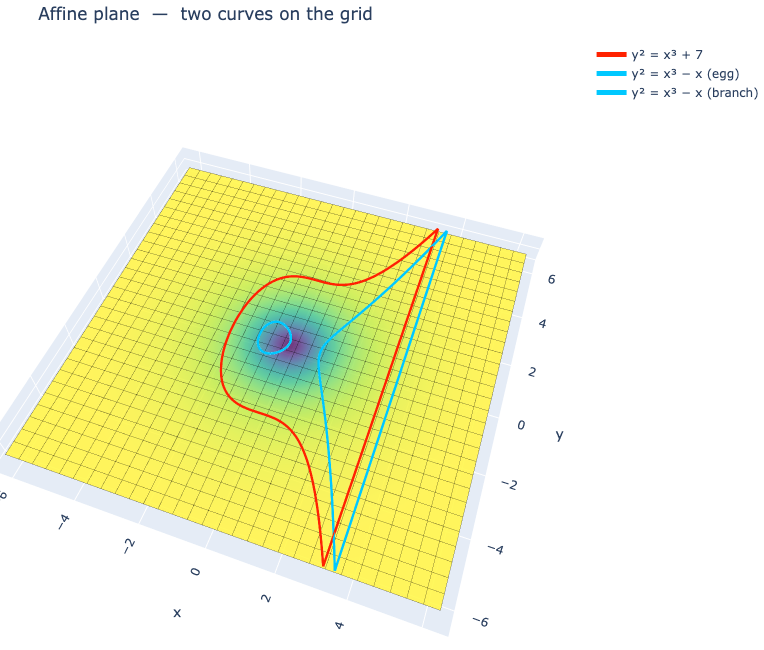

Uniform grid squares. The colour shows where each square lands on the sphere (next cell).


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  AFFINE PLANE — flat grid  +  y² = x³ + 7
# ═══════════════════════════════════════════════════════════════════════
fig_a = go.Figure()

# coloured fill (no contours — we draw the real grid lines ourselves)
fig_a.add_trace(go.Surface(
    x=Xf, y=Yf, z=np.zeros_like(Xf),
    surfacecolor=Zs_f,
    colorscale="Viridis", showscale=False, opacity=0.80,
))

# parametric grid lines
gx, gy, gz = grid_flat
fig_a.add_trace(go.Scatter3d(
    x=gx, y=gy, z=gz,
    mode="lines", line=dict(color=GRID_COLOR, width=GRID_W),
    showlegend=False, hoverinfo="skip",
))

# secp256k1:  y² = x³ + 7  (red)
fig_a.add_trace(go.Scatter3d(
    x=flat_btc_u, y=flat_btc_v, z=np.full(len(flat_btc_u), 0.12),
    mode="lines", line=dict(color="rgb(255,34,0)", width=CURVE_W),
    name="y² = x³ + 7", showlegend=True,
))

# y² = x³ − x  egg (cyan) — clipped to visible range
fig_a.add_trace(go.Scatter3d(
    x=egg_u, y=egg_v, z=np.full(len(egg_u), 0.12),
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x (egg)", showlegend=True,
))
# y² = x³ − x  branch (cyan) — clipped
mask_br_flat = (t_br <= span) & (y_br <= span)
t_brf, y_brf = t_br[mask_br_flat], y_br[mask_br_flat]
fig_a.add_trace(go.Scatter3d(
    x=np.concatenate([t_brf, t_brf[::-1]]),
    y=np.concatenate([y_brf, -y_brf[::-1]]),
    z=np.full(2*len(t_brf), 0.12),
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x (branch)", showlegend=True,
))

fig_a.update_layout(
    title="Affine plane  —  two curves on the grid",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="",
        camera=dict(eye=dict(x=0.4, y=-1.1, z=1.7)),
        zaxis=dict(range=[-0.5, 0.5], showticklabels=False),
        aspectmode="manual", aspectratio=dict(x=1.2, y=1.2, z=0.10),
    ),
    height=650, width=950,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig_a.show()
print("Uniform grid squares. The colour shows where each square lands on the sphere (next cell).")

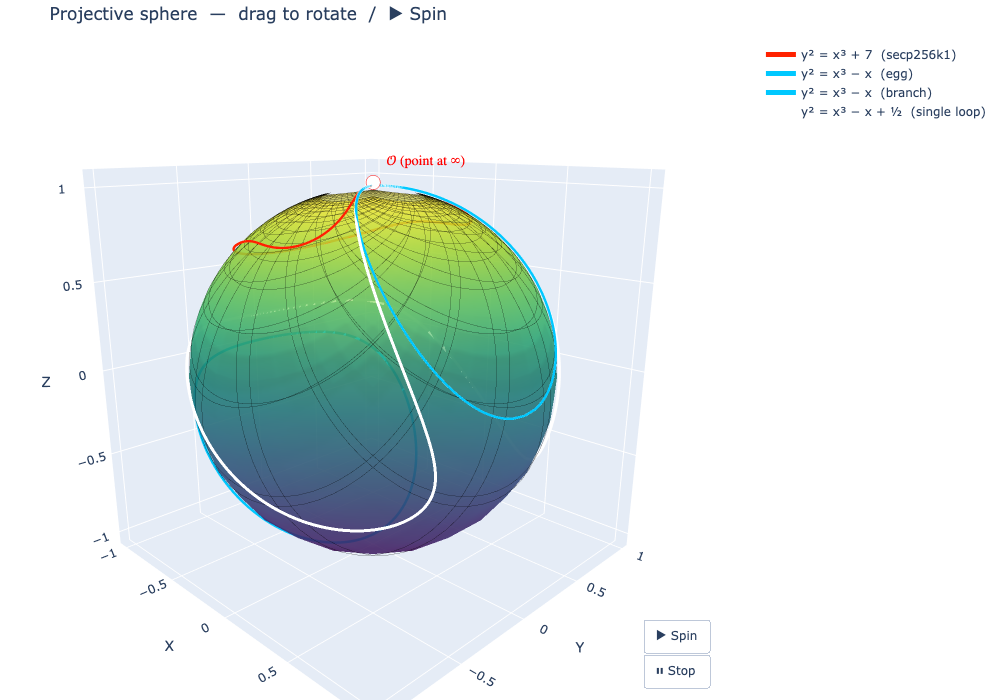

Red   = y² = x³ + 7      (secp256k1)  — small loop hugging the north pole
Cyan  = y² = x³ − x      (2 components — egg + branch, two separate circles)
White = y² = x³ − x + ½  (1 component — single loop sweeping around the sphere)

Toggle each in the legend. The white curve is what the Trustica video shows.


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  PROJECTIVE SPHERE — same grid warped via stereographic projection
#  Drag to rotate, or hit ▶ Spin.
# ═══════════════════════════════════════════════════════════════════════
fig_s = go.Figure()

# coloured fill (no built-in contours)
fig_s.add_trace(go.Surface(
    x=Xs_f, y=Ys_f, z=Zs_f,
    surfacecolor=Zs_f,
    colorscale="Viridis", showscale=False, opacity=0.65,
))

# real warped grid lines (each straight line on the plane becomes a curve here)
gx, gy, gz = grid_sphere
fig_s.add_trace(go.Scatter3d(
    x=gx, y=gy, z=gz,
    mode="lines", line=dict(color=GRID_COLOR, width=GRID_W),
    showlegend=False, hoverinfo="skip",
))

# secp256k1: y² = x³ + 7  (red — hugs upper hemisphere)
fig_s.add_trace(go.Scatter3d(
    x=btc_sx, y=btc_sy, z=btc_sz,
    mode="lines", line=dict(color="rgb(255,34,0)", width=CURVE_W),
    name="y² = x³ + 7  (secp256k1)", showlegend=True,
))

# y² = x³ − x  egg (cyan — loops through lower hemisphere)
fig_s.add_trace(go.Scatter3d(
    x=egg_sx, y=egg_sy, z=egg_sz,
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x  (egg)", showlegend=True,
))

# y² = x³ − x  branch (cyan — sweeps up to north pole)
fig_s.add_trace(go.Scatter3d(
    x=br_sx, y=br_sy, z=br_sz,
    mode="lines", line=dict(color="rgb(0,200,255)", width=CURVE_W),
    name="y² = x³ − x  (branch)", showlegend=True,
))

# y² = x³ − x + 0.5  (white — single big loop wrapping the whole sphere)
fig_s.add_trace(go.Scatter3d(
    x=wrap_sx, y=wrap_sy, z=wrap_sz,
    mode="lines", line=dict(color="white", width=CURVE_W + 1),
    name="y² = x³ − x + ½  (single loop)", showlegend=True,
))

# point at infinity
fig_s.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[1.03],
    mode="markers+text",
    marker=dict(size=8, color="white", line=dict(color="red", width=3)),
    text=["  𝒪 (point at ∞)"], textposition="top right",
    textfont=dict(size=14, color="red", family="serif"),
    showlegend=False,
))

fig_s.update_layout(
    title="Projective sphere  —  drag to rotate  /  ▶ Spin",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        camera=dict(eye=dict(x=1.4, y=-1.4, z=0.6)),
        aspectmode="data",
    ),
    height=700, width=950,
    margin=dict(l=0, r=0, t=40, b=0),
)

# auto-spin
n_frames = 72
frames = []
for i in range(n_frames):
    a = 2 * np.pi * i / n_frames
    frames.append(go.Frame(
        layout=dict(scene=dict(camera=dict(
            eye=dict(x=1.8*np.cos(a), y=1.8*np.sin(a), z=0.6)))),
        name=str(i),
    ))
fig_s.frames = frames
fig_s.update_layout(updatemenus=[dict(
    type="buttons", showactive=False,
    x=0.95, y=0.02, xanchor="right", yanchor="bottom",
    buttons=[
        dict(label="▶ Spin", method="animate",
             args=[None, dict(frame=dict(duration=80, redraw=True),
                              fromcurrent=True, mode="immediate",
                              transition=dict(duration=0))]),
        dict(label="⏸ Stop", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=False),
                                mode="immediate")]),
    ],
)])

fig_s.show()
print("Red   = y² = x³ + 7      (secp256k1)  — small loop hugging the north pole")
print("Cyan  = y² = x³ − x      (2 components — egg + branch, two separate circles)")
print("White = y² = x³ − x + ½  (1 component — single loop sweeping around the sphere)")
print("\nToggle each in the legend. The white curve is what the Trustica video shows.")

### Key Takeaway

Projective space gives us:
1. A well-defined **point at infinity** $\mathcal{O} = [0:1:0]$
2. This point serves as the **identity element** for the group
3. Every line through two curve points intersects the curve at exactly one more point
4. No more edge cases from "parallel lines" — they meet at infinity

---